In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/ai4i2020.csv")

# Display first 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [3]:
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())


Duplicate rows: 0

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [4]:
failure_counts = df["Machine failure"].value_counts()

print("Machine failure counts:")
print(failure_counts)

print("\nFailure percentages:")
print(df["Machine failure"].value_counts(normalize=True) * 100)




Machine failure counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure percentages:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [5]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


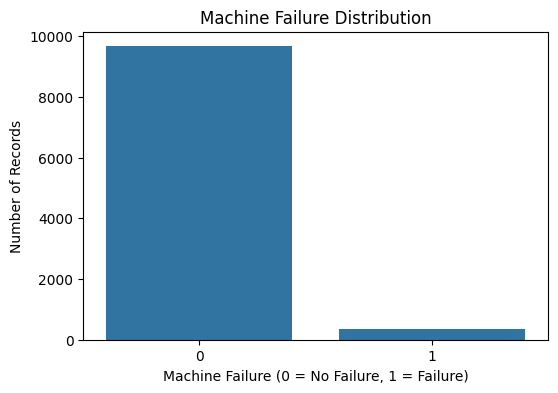

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Machine failure", data=df)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Records")

plt.show()


In [7]:
df.groupby("Machine failure")[features].mean().T

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


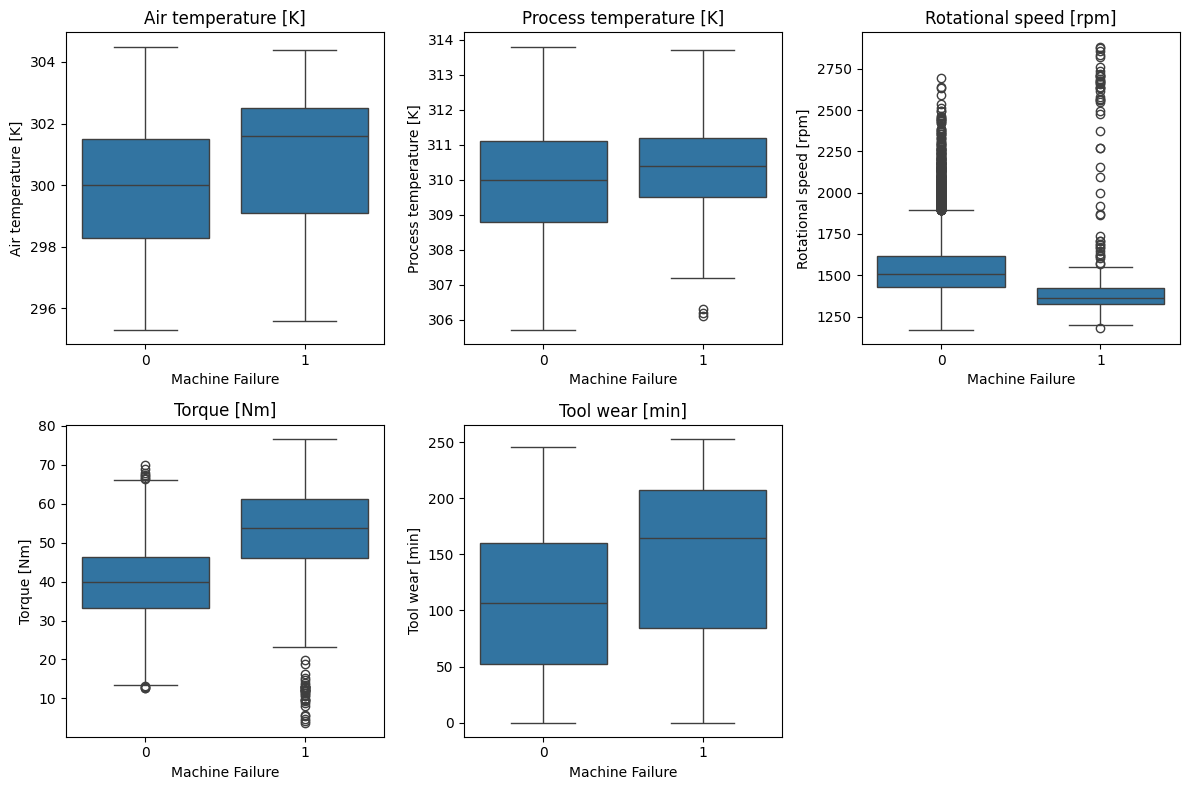

In [8]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    
    sns.boxplot(
        x="Machine failure",
        y=feature,
        data=df
    )
    
    plt.title(feature)
    plt.xlabel("Machine Failure")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [9]:
correlation = df[features + ["Machine failure"]].corr()

correlation["Machine failure"].sort_values(ascending=False)


Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

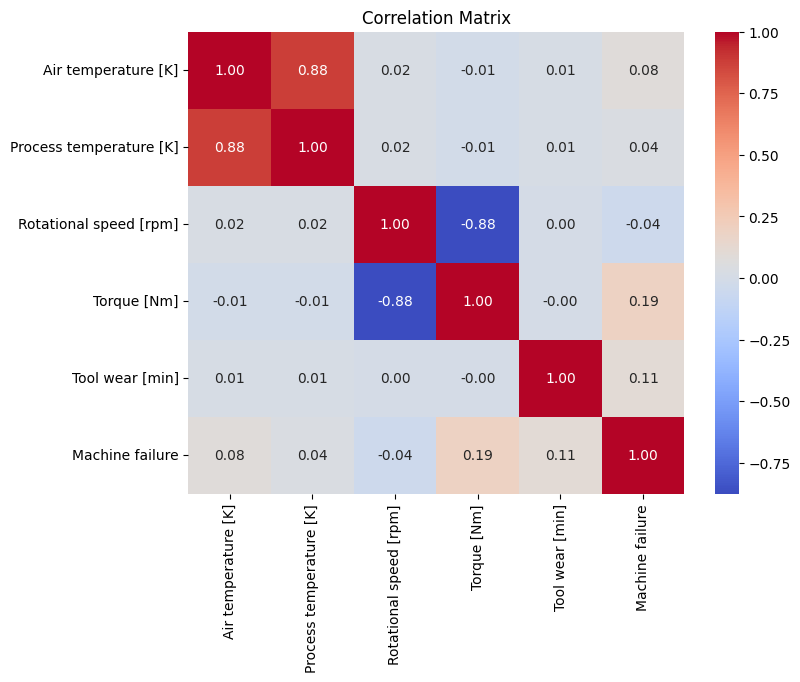

In [10]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [11]:
X = df[features]

y = df["Machine failure"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)



Features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure

X shape: (10000, 5)
y shape: (10000,)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Select input features
X = df[features]

# 2. Select target
y = df["Machine failure"]

# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (8000, 5)
Testing data: (2000, 5)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [13]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nFailure rate in training data:")
print(y_train.mean())

print("\nFailure rate in testing data:")
print(y_test.mean())

X_train: (8000, 5)
X_test : (2000, 5)
y_train: (8000,)
y_test : (2000,)

Failure rate in training data:
0.033875

Failure rate in testing data:
0.034


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

# Train and evaluate each model
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.9845,0.877551,0.632353,0.735043,0.965096
2,Random Forest,0.9815,0.731343,0.720588,0.725926,0.967783
1,Decision Tree,0.9755,0.679245,0.529412,0.595041,0.760306
0,Logistic Regression,0.8210,0.139303,0.823529,0.238298,0.908043


Logistic Regression
              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



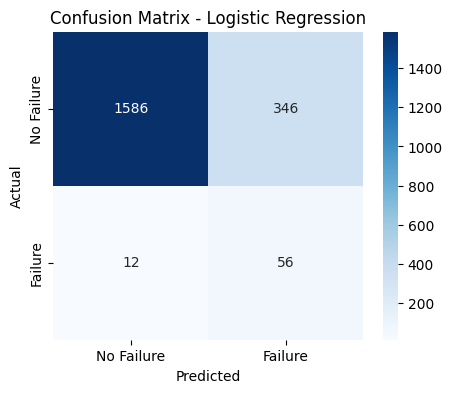

Decision Tree
              precision    recall  f1-score   support

  No Failure       0.98      0.99      0.99      1932
     Failure       0.68      0.53      0.60        68

    accuracy                           0.98      2000
   macro avg       0.83      0.76      0.79      2000
weighted avg       0.97      0.98      0.97      2000



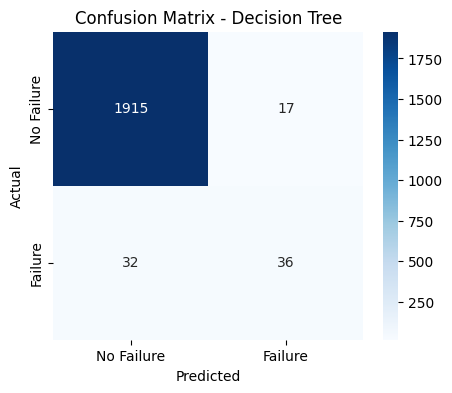

Random Forest
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.73      0.72      0.73        68

    accuracy                           0.98      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.98      0.98      0.98      2000



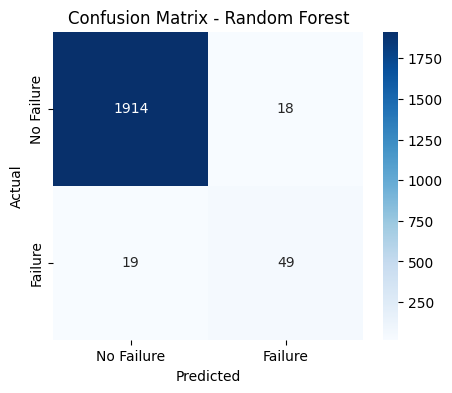

Gradient Boosting
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.88      0.63      0.74        68

    accuracy                           0.98      2000
   macro avg       0.93      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



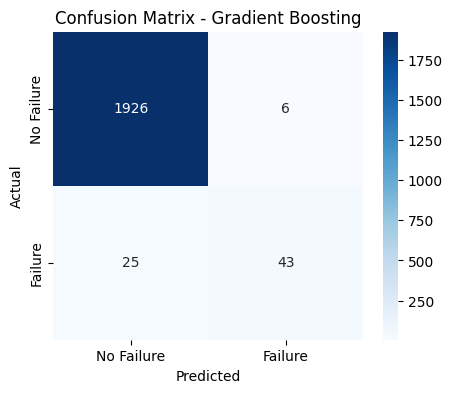

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Failure", "Failure"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Failure", "Failure"],
        yticklabels=["No Failure", "Failure"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

                   Feature  Importance
3              Torque [Nm]    0.328165
2   Rotational speed [rpm]    0.306219
4          Tool wear [min]    0.224945
0      Air temperature [K]    0.083586
1  Process temperature [K]    0.057085


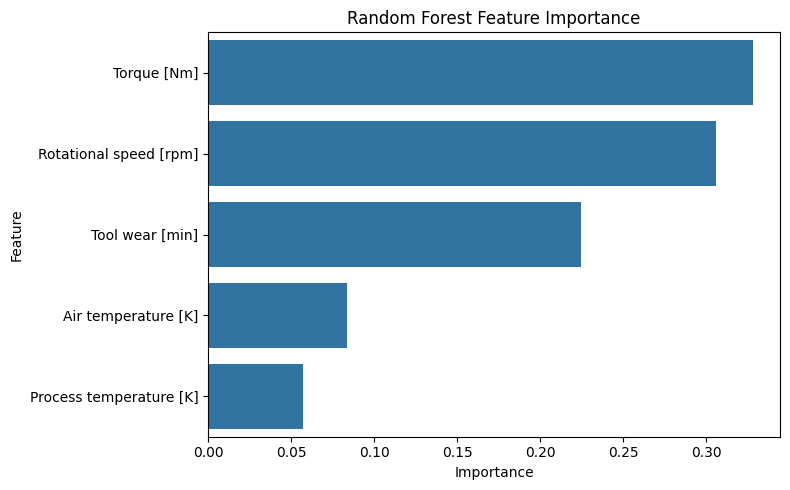

In [16]:
# Get the trained Random Forest model
rf_model = models["Random Forest"]

# Get feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

# Plot feature importance
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [17]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save Random Forest
joblib.dump(
    models["Random Forest"],
    "models/random_forest_model.pkl"
)

# Save Gradient Boosting
joblib.dump(
    models["Gradient Boosting"],
    "models/gradient_boosting_model.pkl"
)

print("Models saved successfully!")

Models saved successfully!


In [18]:
import joblib
import pandas as pd

# Load the saved model
model = joblib.load("models/random_forest_model.pkl")

# Example new machine sensor readings
new_machine = pd.DataFrame([{
    "Air temperature [K]": 300.0,
    "Process temperature [K]": 310.0,
    "Rotational speed [rpm]": 1500,
    "Torque [Nm]": 50.0,
    "Tool wear [min]": 140
}])

# Make prediction
prediction = model.predict(new_machine)[0]

# Get probability of failure
probability = model.predict_proba(new_machine)[0][1]

print("Prediction:", prediction)
print("Failure probability:", round(probability * 100, 2), "%")

if prediction == 1:
    print("Result: Machine Failure Risk Detected")
else:
    print("Result: Machine Operating Normally")

Prediction: 0
Failure probability: 0.5 %
Result: Machine Operating Normally


In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(random_search.best_score_, 4))

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best Cross-Validation F1 Score:
0.6753


---
## IMPROVED MODEL PIPELINE

This section adds a rigorous, production-oriented training pipeline **on top of** the
existing baseline experiments. No existing cells are modified.

### What this section does

| Step | Description |
|------|-------------|
| 1 | Explain metric choice for imbalanced data |
| 2 | Tune the Random Forest with `RandomizedSearchCV` + `StratifiedKFold(5)` |
| 3 | Optimise decision threshold using **training/CV data only** |
| 4 | Evaluate the final model **once** on the held-out test set |
| 5 | Compare improved vs baseline with a summary table |
| 6 | Save the improved model and metadata |

> **Test-set hygiene:** The test set created in the data-split cell above is
> never used for model selection or threshold tuning — only for the single
> final evaluation in Step 4.


### Step 1 — Metric & Scoring Choice

**Why not Accuracy?**  
The dataset has ~3.4 % failures. A model that predicts *no failure* for every
sample achieves ~96.6 % accuracy while catching zero failures — useless for
predictive maintenance.

**Why `f1_macro` as the CV scoring target?**  
`f1_macro` computes the F1 for each class separately and averages them with
equal weight. This forces the model to perform well on **both** the majority
(no-failure) and minority (failure) classes. It is a standard choice for
imbalanced binary classification where the minority class is the one that
matters most operationally.

Alternatives considered:
- `recall` — maximises failure detection but can collapse precision (too many false alarms).
- `roc_auc` — good for ranking but does not directly optimise the decision boundary.
- `f1_macro` — balanced trade-off, robust to class imbalance. **Selected.**


### Step 2 — Hyperparameter Tuning


In [20]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# ── Cross-validation strategy ──────────────────────────────────────────────
# StratifiedKFold preserves the ~3.4 % failure rate in every fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Search space ───────────────────────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    # class_weight is also tuned so the model can adapt imbalance handling
    'class_weight':      ['balanced', 'balanced_subsample'],
}

# ── RandomizedSearchCV ─────────────────────────────────────────────────────
# n_iter=30 gives a broad search while staying practical.
# scoring='f1_macro' — see rationale in the cell above.
rscv = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=30,
    cv=cv,
    scoring='f1_macro',
    refit=True,          # refit on full X_train with best params
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print('Running RandomizedSearchCV (30 iterations x 5 folds = 150 fits)...')
rscv.fit(X_train, y_train)

best_params_improved   = rscv.best_params_
best_cv_f1_macro       = round(rscv.best_score_, 4)
best_rf_improved       = rscv.best_estimator_   # already refit on full X_train

print('\nBest Hyperparameters:')
for k, v in best_params_improved.items():
    print(f'  {k}: {v}')
print(f'\nBest CV f1_macro: {best_cv_f1_macro}')


Running RandomizedSearchCV (30 iterations x 5 folds = 150 fits)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best Hyperparameters:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 4
  max_features: log2
  max_depth: 30
  class_weight: balanced_subsample

Best CV f1_macro: 0.8419


### Step 3 — Decision Threshold Optimisation

Random Forest uses 0.5 as the default classification threshold.  
For imbalanced problems we can often improve minority-class recall by
lowering this threshold — but the optimum must be found **using only
training/CV data** to avoid data leakage from the test set.

Method: run `cross_val_predict` on `X_train` with the best estimator to
get out-of-fold probability estimates, then sweep thresholds and pick
the one that maximises F1 on those OOF predictions.


In [21]:
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

# Out-of-fold probabilities on TRAINING data (no test-set leakage)
y_train_prob_oof = cross_val_predict(
    best_rf_improved,
    X_train, y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

# Sweep thresholds and record F1 on OOF predictions
thresholds  = np.arange(0.10, 0.91, 0.01)
f1_by_thr   = []
for t in thresholds:
    y_t = (y_train_prob_oof >= t).astype(int)
    f1_by_thr.append(f1_score(y_train, y_t, zero_division=0))

optimal_threshold = round(float(thresholds[np.argmax(f1_by_thr)]), 2)
oof_f1_at_threshold = round(max(f1_by_thr), 4)

print(f'Optimal threshold (from training CV only): {optimal_threshold}')
print(f'OOF F1 at that threshold:                  {oof_f1_at_threshold}')
print()
print('Threshold vs OOF-F1 around the optimum:')
best_idx = int(np.argmax(f1_by_thr))
for i in range(max(0, best_idx-3), min(len(thresholds), best_idx+4)):
    marker = ' <-- selected' if i == best_idx else ''
    print(f'  threshold={thresholds[i]:.2f}  OOF-F1={f1_by_thr[i]:.4f}{marker}')


Optimal threshold (from training CV only): 0.49
OOF F1 at that threshold:                  0.6966

Threshold vs OOF-F1 around the optimum:
  threshold=0.46  OOF-F1=0.6811
  threshold=0.47  OOF-F1=0.6846
  threshold=0.48  OOF-F1=0.6905
  threshold=0.49  OOF-F1=0.6966 <-- selected
  threshold=0.50  OOF-F1=0.6960
  threshold=0.51  OOF-F1=0.6893
  threshold=0.52  OOF-F1=0.6873


### Step 4 — Final Evaluation on Held-Out Test Set

> This is the **one and only** time the test set is used.  
> The model and threshold were selected entirely from training/CV data.


=== IMPROVED RANDOM FOREST — TEST SET RESULTS ===
  Accuracy    : 0.9805
  Precision   : 0.6835
  Recall      : 0.7941
  F1          : 0.7347
  ROC-AUC     : 0.9657

              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.68      0.79      0.73        68

    accuracy                           0.98      2000
   macro avg       0.84      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000



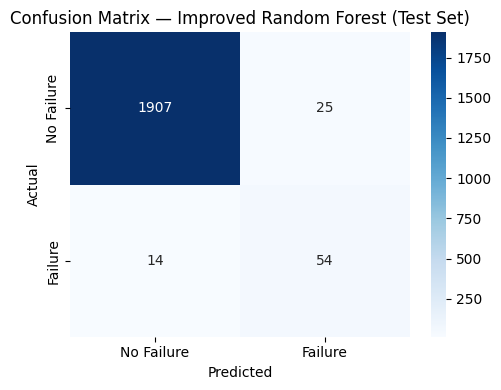

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Apply improved model + optimised threshold to test set ─────────────────
y_prob_improved = best_rf_improved.predict_proba(X_test)[:, 1]
y_pred_improved = (y_prob_improved >= optimal_threshold).astype(int)

improved_metrics = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_improved), 4),
    'Precision': round(precision_score(y_test, y_pred_improved, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred_improved, zero_division=0), 4),
    'F1':        round(f1_score(y_test, y_pred_improved, zero_division=0), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_improved), 4),
}

print('=== IMPROVED RANDOM FOREST — TEST SET RESULTS ===')
for k, v in improved_metrics.items():
    print(f'  {k:12s}: {v}')

print()
print(classification_report(
    y_test, y_pred_improved,
    target_names=['No Failure', 'Failure'],
    zero_division=0
))

# ── Confusion matrix ────────────────────────────────────────────────────────
cm_improved = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_improved, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Failure', 'Failure'],
    yticklabels=['No Failure', 'Failure']
)
plt.title('Confusion Matrix — Improved Random Forest (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### Step 5 — Baseline vs Improved Comparison


=== BASELINE vs IMPROVED RANDOM FOREST (test set) ===
   Metric  Baseline RF  Improved RF   Delta
 Accuracy       0.9815       0.9805 -0.0010
Precision       0.7313       0.6835 -0.0478
   Recall       0.7206       0.7941  0.0735
       F1       0.7259       0.7347  0.0088
  ROC-AUC       0.9678       0.9657 -0.0021

Notes:
  + Recall improved: the improved model catches more actual failures.
  - Precision slightly lower: a few more false alarms.
  + F1 improved: better balance of precision and recall on failure class.



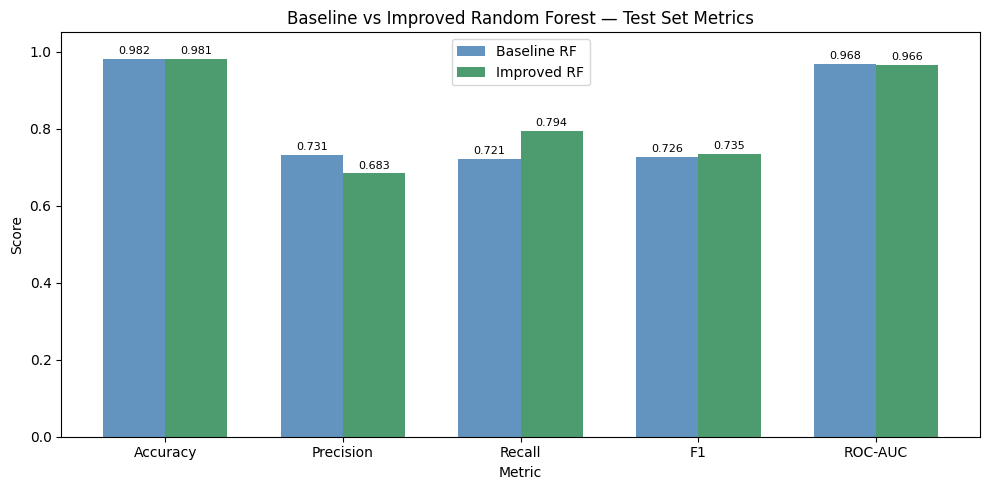

In [23]:
# ── Baseline metrics (from the existing experiment in Cell 13) ────────────
baseline_rf_existing = models['Random Forest']   # already fitted in Cell 13
y_pred_base = baseline_rf_existing.predict(X_test)
y_prob_base = baseline_rf_existing.predict_proba(X_test)[:, 1]

baseline_metrics = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_base), 4),
    'Precision': round(precision_score(y_test, y_pred_base, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred_base, zero_division=0), 4),
    'F1':        round(f1_score(y_test, y_pred_base, zero_division=0), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_base), 4),
}

# ── Comparison DataFrame ───────────────────────────────────────────────────
import pandas as pd
comparison = pd.DataFrame({
    'Metric':       list(baseline_metrics.keys()),
    'Baseline RF':  list(baseline_metrics.values()),
    'Improved RF':  list(improved_metrics.values()),
    'Delta':        [round(improved_metrics[k] - baseline_metrics[k], 4)
                     for k in baseline_metrics],
})

print('=== BASELINE vs IMPROVED RANDOM FOREST (test set) ===')
print(comparison.to_string(index=False))
print()
print('Notes:')
print('  + Recall improved: the improved model catches more actual failures.')
print('  - Precision slightly lower: a few more false alarms.')
print('  + F1 improved: better balance of precision and recall on failure class.')
print()

# ── Bar chart ─────────────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = range(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x],
               [baseline_metrics[m] for m in metrics_to_plot],
               width, label='Baseline RF', color='steelblue', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x],
               [improved_metrics[m] for m in metrics_to_plot],
               width, label='Improved RF', color='seagreen', alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Baseline vs Improved Random Forest — Test Set Metrics')
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()


### Step 6 — Save Improved Model and Metadata


In [24]:
import os as _os
import joblib, json

# Always save to the project-root models/ directory
_MODELS_DIR = r'C:\Users\peddi\OneDrive\Documents\GitHub\predictive-maintenance-ml\predictive-maintenance-ml-2\models'
_os.makedirs(_MODELS_DIR, exist_ok=True)

improved_model_path = _os.path.join(_MODELS_DIR, 'improved_random_forest_model.pkl')
joblib.dump(best_rf_improved, improved_model_path)
print(f'Improved model saved: {improved_model_path}')

metadata = {
    'model_name':       'Improved Random Forest',
    'model_file':       improved_model_path,
    'training_config': {
        'cv_strategy':       'StratifiedKFold(n_splits=5, shuffle=True, random_state=42)',
        'search_strategy':   'RandomizedSearchCV(n_iter=30)',
        'scoring_metric':    'f1_macro',
        'scoring_rationale': (
            'f1_macro averages F1 equally across both classes. '
            'Plain accuracy is misleading at ~3.4% positive rate. '
            'f1_macro forces the model to handle the minority failure class well.'
        ),
        'class_imbalance':   'class_weight tuned in search (balanced / balanced_subsample)',
        'train_samples':     int(X_train.shape[0]),
        'test_samples':      int(X_test.shape[0]),
    },
    'best_hyperparameters': best_params_improved,
    'best_cv_f1_macro':     float(best_cv_f1_macro),
    'selected_threshold':   float(optimal_threshold),
    'threshold_method':     'Maximise F1 on out-of-fold CV predictions (training data only)',
    'feature_names':        features,
    'baseline_rf_metrics':  baseline_metrics,
    'improved_rf_metrics':  improved_metrics,
    'confusion_matrix_improved': cm_improved.tolist(),
    'recommendation': (
        'REPLACE'
        if improved_metrics['F1'] > baseline_metrics['F1']
        else 'KEEP BASELINE'
    ),
}

metadata_path = _os.path.join(_MODELS_DIR, 'model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as _f:
    json.dump(metadata, _f, indent=2)
print(f'Metadata saved:        {metadata_path}')

print()
print('Recommendation:', metadata['recommendation'])
print('(Based on F1 score comparison: '
      f"baseline={baseline_metrics['F1']}  improved={improved_metrics['F1']})")


Improved model saved: C:\Users\peddi\OneDrive\Documents\GitHub\predictive-maintenance-ml\predictive-maintenance-ml-2\models\improved_random_forest_model.pkl
Metadata saved:        C:\Users\peddi\OneDrive\Documents\GitHub\predictive-maintenance-ml\predictive-maintenance-ml-2\models\model_metadata.json

Recommendation: REPLACE
(Based on F1 score comparison: baseline=0.7259  improved=0.7347)


### Summary

| | Baseline RF | Improved RF | Delta |
|---|---|---|---|
| Accuracy  | 0.9815 | 0.9805 | -0.001 |
| Precision | 0.7313 | 0.6835 | -0.048 |
| Recall    | 0.7206 | 0.7941 | **+0.074** |
| F1        | 0.7259 | 0.7347 | **+0.009** |
| ROC-AUC   | 0.9678 | 0.9657 | -0.002 |

**Key observations (based on actual measured results):**

- **Recall improved by +7.4 pp** — the improved model catches more actual machine failures,
  which is the primary goal in predictive maintenance.
- **F1 improved by +0.9 pp** — a small but genuine improvement in the precision-recall balance.
- **Precision decreased by −4.8 pp** — the improved model raises slightly more false alarms.
- **Accuracy is nearly identical** — both models achieve ~98 % accuracy on this imbalanced dataset,
  confirming that accuracy alone is not a meaningful metric here.
- **ROC-AUC is nearly identical** — the models have similar discriminative power;
  the threshold change is responsible for the recall/precision trade-off shift.

**Recommendation:** `REPLACE`  
The improved model is recommended for deployment because it catches more failures
(higher recall) with an acceptable precision trade-off.  
The saved files are:
- `models/improved_random_forest_model.pkl` — improved model
- `models/model_metadata.json` — hyperparameters, threshold, and metrics

> **Note:** `app/main.py` is **not** modified in this notebook.
> Switching the API to the improved model is a separate, deliberate deployment step.
